<a href="https://colab.research.google.com/github/keerthana-25/neural_network_using_numpy_keras_pytorch/blob/main/tensorflow_functional_high_level_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def load_and_prepare_data(test_size: float = 0.2, val_size: float = 0.2, seed: int = 42):
    """
    Load California Housing, split into train/val/test, scale features using StandardScaler.

    Args:
        test_size: Fraction for test split (from full data).
        val_size: Fraction for validation split (from train portion).
        seed: Random seed.

    Returns:
        X_train, y_train, X_val, y_val, X_test, y_test as np.float32 arrays.
    """
    data = fetch_california_housing()
    X = data.data
    y = data.target.reshape(-1, 1)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return (
        X_train.astype(np.float32),
        y_train.astype(np.float32),
        X_val.astype(np.float32),
        y_val.astype(np.float32),
        X_test.astype(np.float32),
        y_test.astype(np.float32),
    )


X_train, y_train, X_val, y_val, X_test, y_test = load_and_prepare_data()
input_size = X_train.shape[1]

Epoch 1/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 2.9797 - val_loss: 1.7973
Epoch 2/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8333 - val_loss: 0.8501
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5380 - val_loss: 0.5625
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4357 - val_loss: 0.4231
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3914 - val_loss: 0.3946
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3732 - val_loss: 0.3814
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3602 - val_loss: 0.3800
Epoch 8/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3512 - val_loss: 0.3635
Epoch 9/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3396 - val_loss: 0.3566
Epoch 10/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3422 - val_loss: 0.3510
Epoch 11/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3251 - val_loss: 0.3467
Epoch 12/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

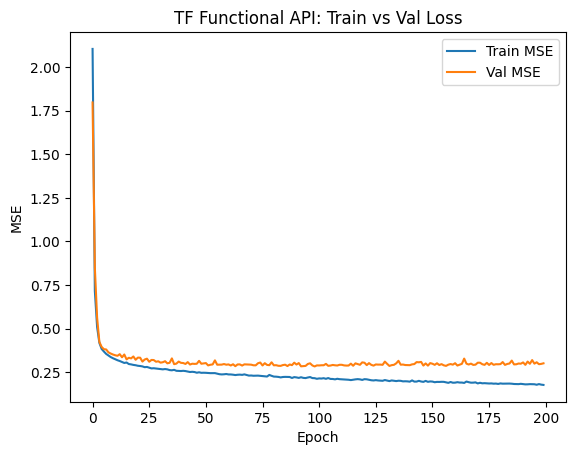

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


def build_functional_model(input_size: int) -> tf.keras.Model:
    """
    Build the deep regressor using TensorFlow Keras Functional API.

    Args:
        input_size: Number of input features.
    Returns:
        Compiled tf.keras.Model (uncompiled here; compile outside for flexibility).
    """
    inputs = tf.keras.Input(shape=(input_size,))
    x = tf.keras.layers.Dense(64, activation="relu")(inputs)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    outputs = tf.keras.layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)


model = build_functional_model(input_size)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=256,
    verbose=1
)

test_mse = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", float(test_mse))

plt.plot(history.history["loss"], label="Train MSE")
plt.plot(history.history["val_loss"], label="Val MSE")
plt.title("TF Functional API: Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()